In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# make plots look better
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (8,5)

In [6]:
from google.colab import files

uploaded = files.upload()

Saving E-commerce Customer Behavior - Sheet1.csv to E-commerce Customer Behavior - Sheet1 (1).csv


In [7]:
df = pd.read_csv('E-commerce Customer Behavior - Sheet1.csv')

In [8]:
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [9]:
df.shape

(350, 11)

In [10]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'City', 'Membership Type',
       'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied',
       'Days Since Last Purchase', 'Satisfaction Level'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


In [12]:
df.describe()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,275.500000,33.597143,845.381714,12.600000,4.019143,26.588571
std,101.180532,4.870882,362.058695,4.155984,0.580539,13.440813
min,101.000000,26.000000,410.800000,7.000000,3.000000,9.000000
25%,188.250000,30.000000,502.000000,9.000000,3.500000,15.000000
50%,275.500000,32.500000,775.200000,12.000000,4.100000,23.000000
75%,362.750000,37.000000,1160.600000,15.000000,4.500000,38.000000
max,450.000000,43.000000,1520.100000,21.000000,4.900000,63.000000


# Data Cleaning


In [13]:
df_clean = df.copy()

In [14]:
df_clean.isnull().sum()

,0
Customer ID,0
Gender,0
Age,0
City,0
Membership Type,0
Total Spend,0
Items Purchased,0
Average Rating,0
Discount Applied,0
Days Since Last Purchase,0


In [15]:
df_clean["Satisfaction Level"].fillna(df["Satisfaction Level"].mode()[0], inplace=True)

/tmp/ipykernel_1705/2911678705.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean["Satisfaction Level"].fillna(df["Satisfaction Level"].mode()[0], inplace=True)


In [16]:
df_clean.isnull().sum()

,0
Customer ID,0
Gender,0
Age,0
City,0
Membership Type,0
Total Spend,0
Items Purchased,0
Average Rating,0
Discount Applied,0
Days Since Last Purchase,0


In [17]:
df["Satisfaction Level"].fillna(df["Satisfaction Level"].mode()[0], inplace=True)

/tmp/ipykernel_1705/4230081484.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Satisfaction Level"].fillna(df["Satisfaction Level"].mode()[0], inplace=True)


In [18]:
df_clean.duplicated().sum()

np.int64(0)

In [19]:
df_clean.dtypes

,0
Customer ID,int64
Gender,object
Age,int64
City,object
Membership Type,object
Total Spend,float64
Items Purchased,int64
Average Rating,float64
Discount Applied,bool
Days Since Last Purchase,int64


In [20]:
df_clean.columns = df_clean.columns.str.strip().str.replace(" ", "_")

In [21]:
df_clean.columns

Index(['Customer_ID', 'Gender', 'Age', 'City', 'Membership_Type',
       'Total_Spend', 'Items_Purchased', 'Average_Rating', 'Discount_Applied',
       'Days_Since_Last_Purchase', 'Satisfaction_Level'],
      dtype='object')

In [22]:
df_clean['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [23]:
df_clean['Membership_Type'].unique()

array(['Gold', 'Silver', 'Bronze'], dtype=object)

In [24]:
df_clean['Satisfaction_Level'].unique()

array(['Satisfied', 'Neutral', 'Unsatisfied'], dtype=object)

In [25]:
df_clean["Gender"].value_counts()

,count
Gender,
Female,175
Male,175


In [26]:
df_clean["Membership_Type"].value_counts()

,count
Membership_Type,
Gold,117
Silver,117
Bronze,116


In [27]:
df_clean["Satisfaction_Level"].value_counts()

,count
Satisfaction_Level,
Satisfied,127
Unsatisfied,116
Neutral,107


In [28]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership_Type           350 non-null    object 
 5   Total_Spend               350 non-null    float64
 6   Items_Purchased           350 non-null    int64  
 7   Average_Rating            350 non-null    float64
 8   Discount_Applied          350 non-null    bool   
 9   Days_Since_Last_Purchase  350 non-null    int64  
 10  Satisfaction_Level        350 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


In [29]:
df_clean.to_csv("Cleaned_Customer_Behavior.csv", index=False)

In [30]:
files.download("Cleaned_Customer_Behavior.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# EDA

In [31]:
plt.style.use('ggplot')

In [32]:
df_clean.select_dtypes(include=['int64', 'float64']).columns

Index(['Customer_ID', 'Age', 'Total_Spend', 'Items_Purchased',
       'Average_Rating', 'Days_Since_Last_Purchase'],
      dtype='object')

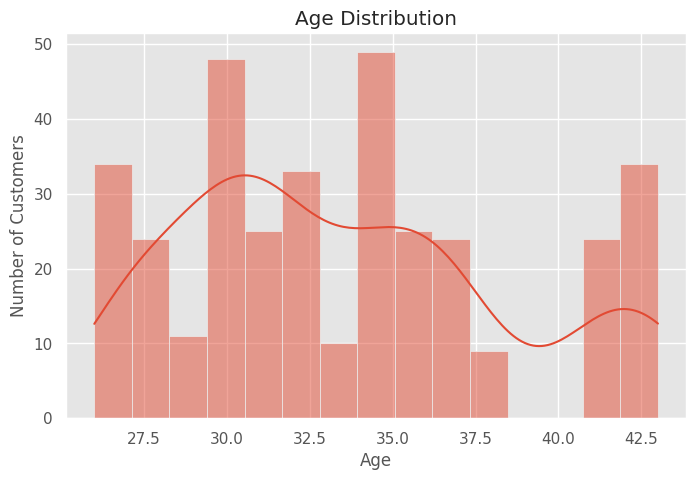

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean["Age"], bins=15, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

Most customers are between 30 and 35 years of age.

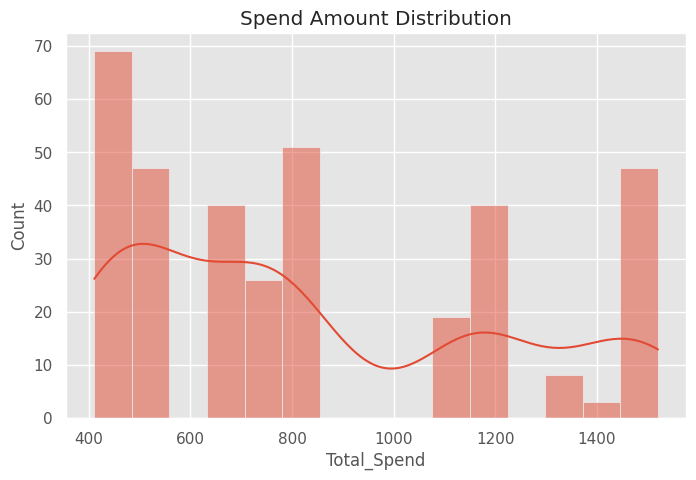

In [34]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean["Total_Spend"], bins=15, kde=True)
plt.title("Spend Amount Distribution")
plt.show()

In [35]:
df_clean.select_dtypes(include=['object']).columns

Index(['Gender', 'City', 'Membership_Type', 'Satisfaction_Level'], dtype='object')

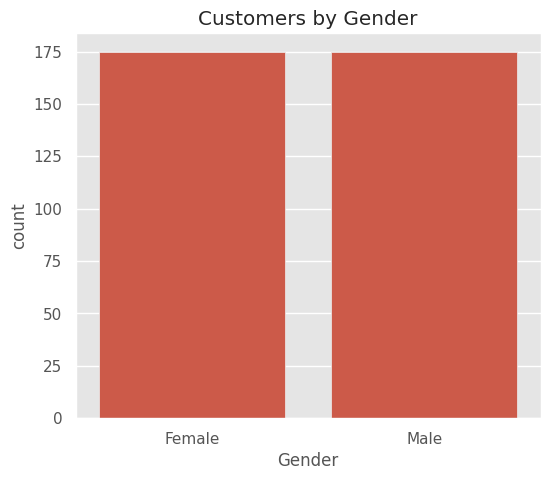

In [36]:
plt.figure(figsize=(6,5))
sns.countplot(data=df_clean, x="Gender")
plt.title("Customers by Gender")
plt.show()

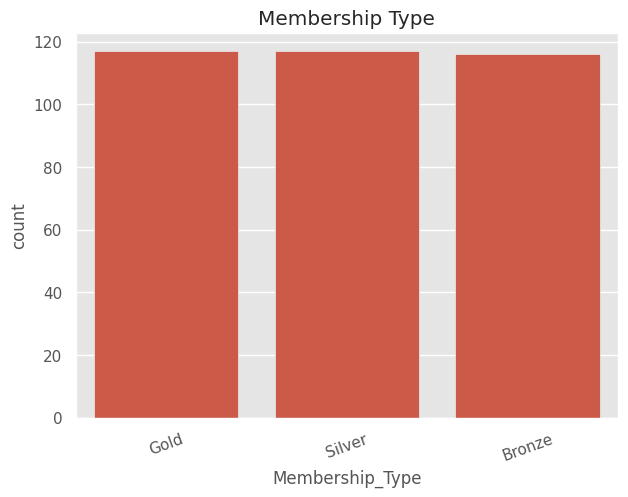

In [37]:
plt.figure(figsize=(7,5))
sns.countplot(data=df_clean, x="Membership_Type")
plt.title("Membership Type")
plt.xticks(rotation=20)
plt.show()

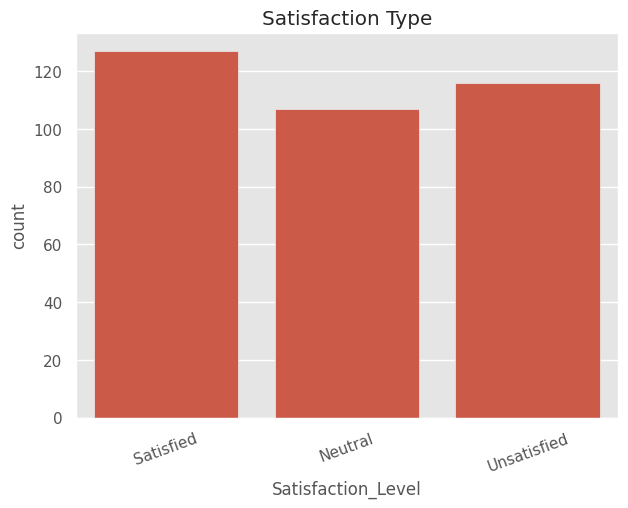

In [38]:
plt.figure(figsize=(7,5))
sns.countplot(data=df_clean, x="Satisfaction_Level")
plt.title("Satisfaction Type")
plt.xticks(rotation=20)
plt.show()

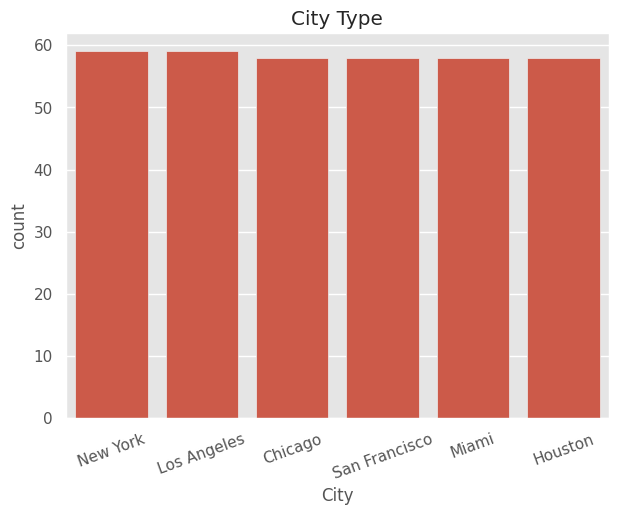

In [39]:
plt.figure(figsize=(7,5))
sns.countplot(data=df_clean, x="City")
plt.title("City Type")
plt.xticks(rotation=20)
plt.show()

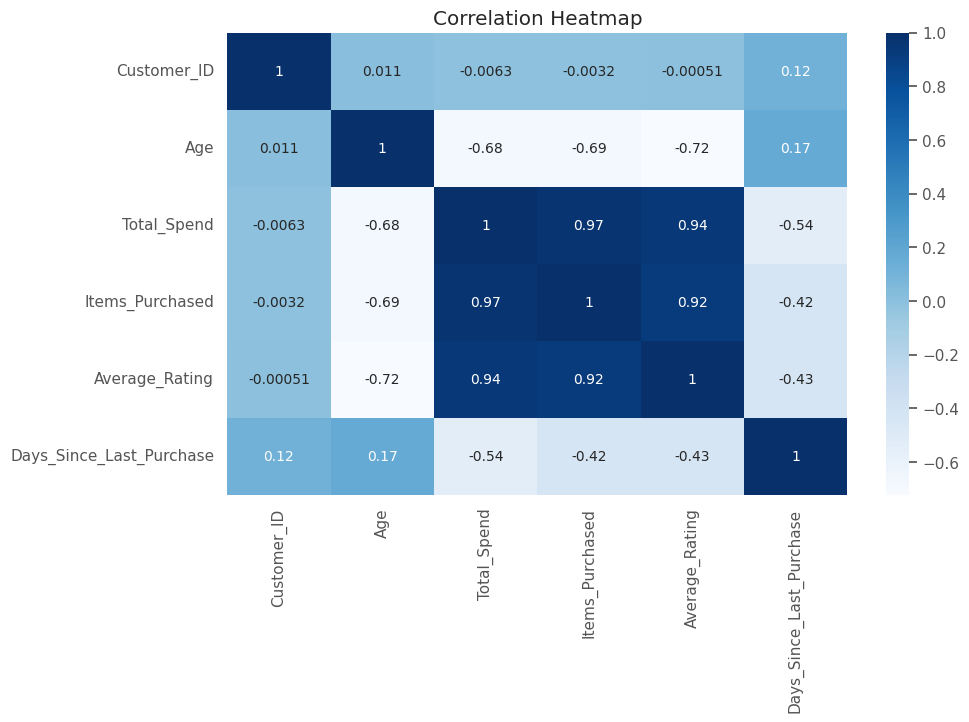

In [40]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df_clean.select_dtypes(include=['int64','float64']).corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")
plt.show()

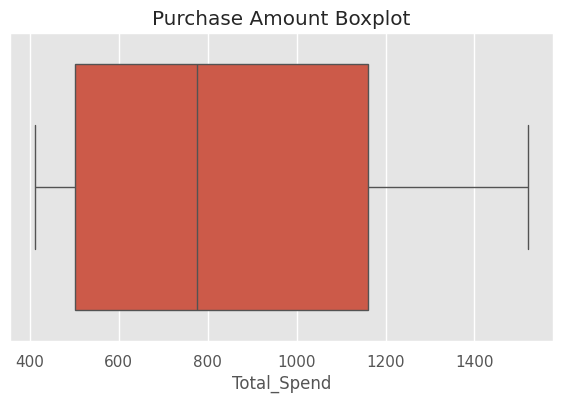

In [41]:
plt.figure(figsize=(7,4))

sns.boxplot(x=df_clean["Total_Spend"])

plt.title("Purchase Amount Boxplot")
plt.show()

# Feature Selection and K-mean clustering

In [42]:
df_clean.columns

Index(['Customer_ID', 'Gender', 'Age', 'City', 'Membership_Type',
       'Total_Spend', 'Items_Purchased', 'Average_Rating', 'Discount_Applied',
       'Days_Since_Last_Purchase', 'Satisfaction_Level'],
      dtype='object')

In [43]:
df_cluster = df_clean.drop("Customer_ID", axis=1)

In [44]:
X = df_cluster.copy()

In [45]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Gender                    350 non-null    object 
 1   Age                       350 non-null    int64  
 2   City                      350 non-null    object 
 3   Membership_Type           350 non-null    object 
 4   Total_Spend               350 non-null    float64
 5   Items_Purchased           350 non-null    int64  
 6   Average_Rating            350 non-null    float64
 7   Discount_Applied          350 non-null    bool   
 8   Days_Since_Last_Purchase  350 non-null    int64  
 9   Satisfaction_Level        350 non-null    object 
dtypes: bool(1), float64(2), int64(3), object(4)
memory usage: 25.1+ KB


In [46]:
X = pd.get_dummies(
    X,
    columns=[
        "Gender",
        "City",
        "Membership_Type",
        "Discount_Applied"
    ],
    drop_first=True
)

In [47]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       350 non-null    int64  
 1   Total_Spend               350 non-null    float64
 2   Items_Purchased           350 non-null    int64  
 3   Average_Rating            350 non-null    float64
 4   Days_Since_Last_Purchase  350 non-null    int64  
 5   Satisfaction_Level        350 non-null    object 
 6   Gender_Male               350 non-null    bool   
 7   City_Houston              350 non-null    bool   
 8   City_Los Angeles          350 non-null    bool   
 9   City_Miami                350 non-null    bool   
 10  City_New York             350 non-null    bool   
 11  City_San Francisco        350 non-null    bool   
 12  Membership_Type_Gold      350 non-null    bool   
 13  Membership_Type_Silver    350 non-null    bool   
 14  Discount_A

In [48]:
df_clean["Satisfaction_Level"] = df_clean["Satisfaction_Level"].map({
    "Unsatisfied": 1,
    "Neutral": 2,
    "Satisfied": 3
})

In [49]:
X = df_clean.drop("Customer_ID", axis=1)

X = pd.get_dummies(
    X,
    columns=[
        "Gender",
        "City",
        "Membership_Type",
        "Discount_Applied"
    ],
    drop_first=True
)

In [50]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       350 non-null    int64  
 1   Total_Spend               350 non-null    float64
 2   Items_Purchased           350 non-null    int64  
 3   Average_Rating            350 non-null    float64
 4   Days_Since_Last_Purchase  350 non-null    int64  
 5   Satisfaction_Level        350 non-null    int64  
 6   Gender_Male               350 non-null    bool   
 7   City_Houston              350 non-null    bool   
 8   City_Los Angeles          350 non-null    bool   
 9   City_Miami                350 non-null    bool   
 10  City_New York             350 non-null    bool   
 11  City_San Francisco        350 non-null    bool   
 12  Membership_Type_Gold      350 non-null    bool   
 13  Membership_Type_Silver    350 non-null    bool   
 14  Discount_A

In [51]:
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

In [52]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       350 non-null    int64  
 1   Total_Spend               350 non-null    float64
 2   Items_Purchased           350 non-null    int64  
 3   Average_Rating            350 non-null    float64
 4   Days_Since_Last_Purchase  350 non-null    int64  
 5   Satisfaction_Level        350 non-null    int64  
 6   Gender_Male               350 non-null    int64  
 7   City_Houston              350 non-null    int64  
 8   City_Los Angeles          350 non-null    int64  
 9   City_Miami                350 non-null    int64  
 10  City_New York             350 non-null    int64  
 11  City_San Francisco        350 non-null    int64  
 12  Membership_Type_Gold      350 non-null    int64  
 13  Membership_Type_Silver    350 non-null    int64  
 14  Discount_A

In [53]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [54]:
wcss = []

In [55]:
for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

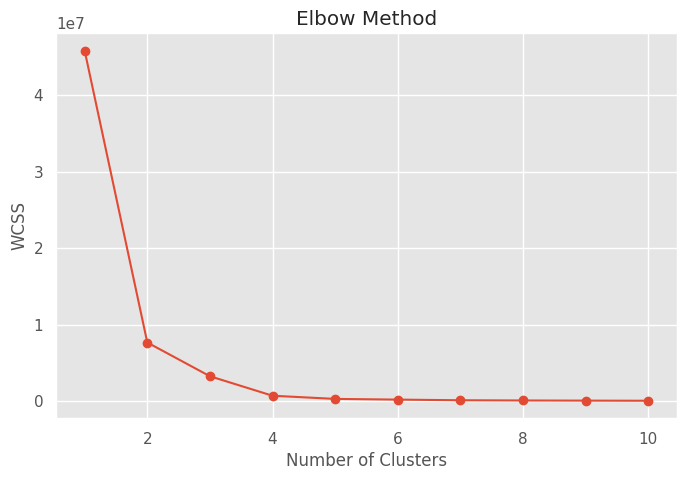

In [56]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [57]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    init='k-means++',
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X)

In [58]:
df_clean["Cluster"] = clusters

In [59]:
df_clean.head()

,Customer_ID,Gender,Age,City,Membership_Type,Total_Spend,Items_Purchased,Average_Rating,Discount_Applied,Days_Since_Last_Purchase,Satisfaction_Level,Cluster
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,3,1
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,2,2
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,1,0
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,3,3
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,1,2


In [60]:
df_clean["Cluster"].value_counts().sort_index()

,count
Cluster,
0,116
1,59
2,117
3,58


In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [62]:
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=X.columns
)

cluster_centers

,Age,Total_Spend,Items_Purchased,Average_Rating,Days_Since_Last_Purchase,Satisfaction_Level,Gender_Male,City_Houston,City_Los Angeles,City_Miami,City_New York,City_San Francisco,Membership_Type_Gold,Membership_Type_Silver,Discount_Applied_True
0,225.051050,171994.886068,47.839590,5.946674,450.873059,3.294752,0.500000,0.351626,0.168571,0.165714,0.168571,0.165714,0.334286,0.334286,0.750000
1,182.977158,422053.630069,75.976081,6.653378,356.668893,4.529364,0.508475,0.165714,0.168571,0.165714,0.542944,0.165714,0.806026,0.334286,1.000000
2,187.080803,271434.482314,60.981698,6.367706,432.677953,3.340888,0.995726,0.165714,0.357358,0.350037,0.168571,0.165714,0.334286,0.806026,0.747863
3,175.237813,528613.103996,95.600861,6.806742,176.540220,4.529364,1.000000,0.165714,0.168571,0.165714,0.168571,0.537538,0.806026,0.334286,0.500000


In [63]:
cluster_summary = df_clean.groupby("Cluster").mean(numeric_only=True)
cluster_summary

,Customer_ID,Age,Total_Spend,Items_Purchased,Average_Rating,Discount_Applied,Days_Since_Last_Purchase,Satisfaction_Level
Cluster,,,,,,,,
0,276.362069,39.362069,473.388793,8.491379,3.325000,0.500000,31.612069,1.517241
1,274.576271,30.711864,1165.035593,15.271186,4.544068,1.000000,24.593220,3.000000
2,275.572650,31.555556,748.432479,11.658120,4.051282,0.495726,30.256410,1.572650
3,274.568966,29.120690,1459.772414,20.000000,4.808621,0.000000,11.172414,3.000000


In [64]:
df_clean.to_csv("Clustered_Customers.csv", index=False)

In [65]:
files.download("Clustered_Customers.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>